# ガイドカメラ(Atik314L+)に天体導入後、赤道儀による追尾を補助するプログラムを試作

In [20]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import plotly.express as px
import astropy
from astropy.io import fits

# 画像加工用
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from sklearn.decomposition import PCA


# 1. initial-parameter setting

In [ ]:
# general parameter
root_path = Path().absolute()
images_path = root_path / 'images'
slit_guide_images_path = images_path / '02_slit_guide_images'
src_path = root_path / 'src'


# 2. capturing image of slit-guide camera
別で用意しているのでskip

# 3. detecting target source position


In [ ]:
# 確認画像の設定
# latest_slit_guide_image = slit_guide_images_path / 'latest.fits'  本番用
latest_image_path = slit_guide_images_path / "test_01.fits"

### 3-1. slit位置の特定

In [77]:
def convert_fits_to_2d_array(_fits: fits.HDUList)->np.ndarray:
    '''
    FITS ファイルを2次元行列に変換する関数
    input:
        _fits: 変換したいFITSファイル
    output:
        data: 2次元行列(array型)
    '''
    with fits.open(_fits) as hdul:
        data = hdul[0].data
    return data

def draw_color_map(_data: np.ndarray)->None:
    '''
    2次元行列をカラーマップで可視化する関数
    input:
        _data: 可視化したい2次元行列(array型)
    output:
        None
    '''
    plt.figure(figsize=(8, 6))
    plt.imshow(_data, cmap="viridis", origin="lower")
    plt.colorbar(label='Pixel Value')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

def draw_map_and_spot(_data: np.ndarray, _dot_x, _dot_y)->None:
    '''
    2次元行列をカラーマップで可視化し、重心点を赤色で表示する関数
    input:
        _data: 可視化したい2次元行列(array型)
        _dot_x: 重心点のx座標
        _dot_y: 重心点のy座標
    '''
    plt.figure(figsize=(8, 6))
    plt.imshow(_data, cmap="viridis", origin="lower")
    plt.colorbar(label='Pixel Value')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.scatter(_dot_x, _dot_y, color='red', s=30, marker='o', label='centroid')
    plt.legend()

def detect_slit_center(_data: np.ndarray)->tuple:
    '''
    スリット中心点を推定する関数
    input:
        _data: 2次元行列(array型)
    output:
        cx: 重心点のx座標
        cy: 重心点のy座標
    '''
    # 暗領域を特定（暗いpixel間を連結して領域を作り、複数の暗領域を特定する）
    data_smoothing = gaussian_filter(_data, sigma=5)  # 平滑化
    data_residual = _data - data_smoothing  # raw-平滑化で暗い構造を抽出
    threshold_black_region = np.percentile(data_residual, 5)
    data_binary = data_residual < threshold_black_region

    # 2番目に長い暗領域(スリット)の重心を推定
    label_img = label(data_binary)
    regions = regionprops(label_img)
    sorted_regions = sorted(
        regions,
        key=lambda r: r.axis_major_length,
        reverse=True
    )
    target_region = sorted_regions[1]
    cy, cx = target_region.centroid  # 重心
    return cx, cy

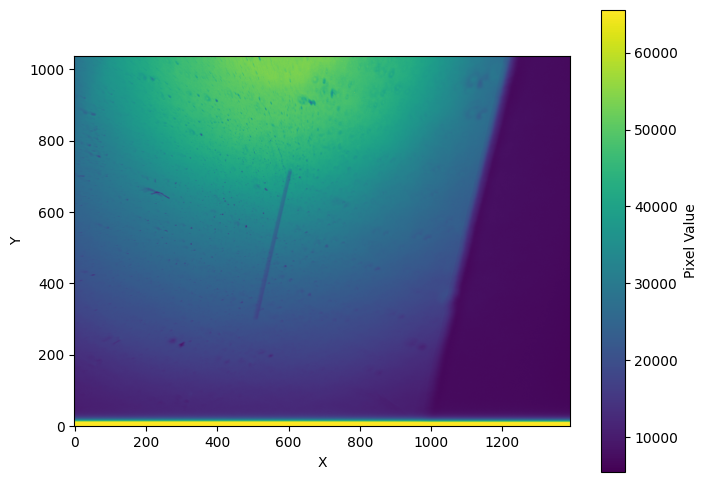

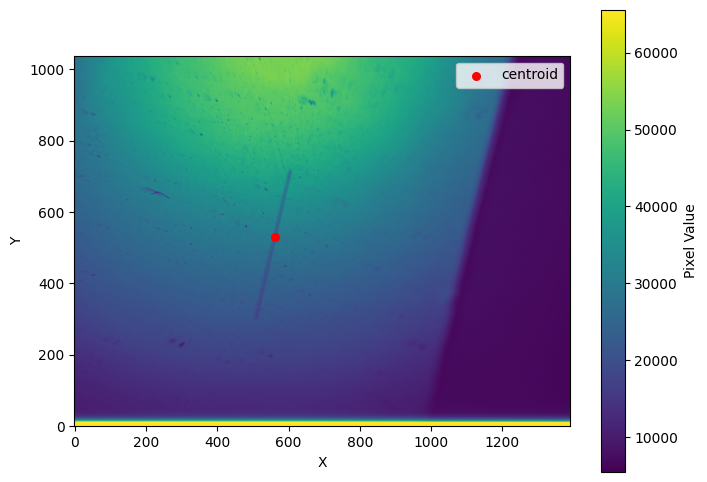

In [78]:
# 対象の画像を可視化
data_raw = convert_fits_to_2d_array(latest_image_path)
draw_color_map(data_raw)

# スリット中心点を推定
cx, cy = detect_slit_center(data_raw)
draw_map_and_spot(data_raw, cx, cy)

### 3-2. 光源の特定

# 4. calculating distance between target source and slit center


# 5. converting distance unit to radec

# 6. transport fixed-radec-infomation(json)